In [1]:
import scarf
import scarf.plotting as splt

scarf.set_verbosity('WARNING')

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    'tenx_5K_pbmc_rnaseq',
    destination='scarf_datasets',
)

In [2]:
reader = scarf.CrH5Reader(f'{dataset}/data.h5')
reader.nCells, reader.nFeatures

(5025, 33538)

In [3]:
writer = scarf.CrToZarr(
    reader,
    zarr_loc=f'{dataset}/data.zarr',
)
writer.dump(batch_size=1000)

In [4]:
ds = scarf.DataStore(
    f'{dataset}/data.zarr',
    nthreads=4,
    min_features_per_cell=10
)
ds

Minimum cell count (502) is lower than size factor multiplier (1000)



DataStore has 5025 (5025) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_percentMito', 'RNA_nFeatures', 
            'RNA_percentRibo', 'RNA_nCounts'
   RNA assay has 14283 (33538) features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'nCells', 
          

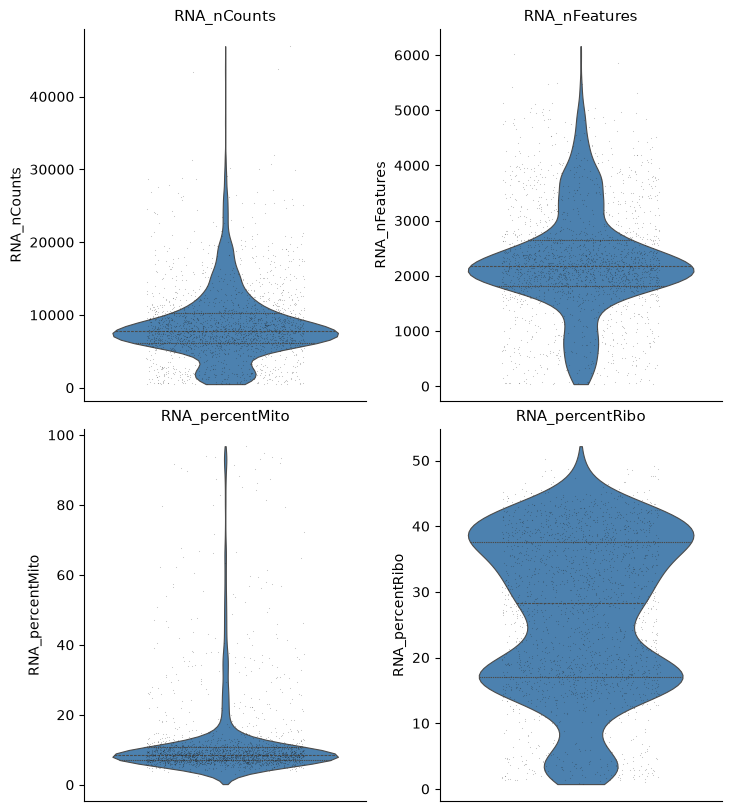

In [5]:
qc_cols = [
    c for c in (
        'RNA_nCounts', 'RNA_nFeatures', 'RNA_percentMito', 'RNA_percentRibo'
    )
    if c in ds.cells.columns
]
ds.plots.distribution(
    keys=qc_cols,
    kind='violin',
    max_points=2000,
)

In [6]:
n_before = int(ds.cells.fetch_all('I').sum())
ds.filter_cells(
    attrs=['RNA_nCounts', 'RNA_nFeatures', 'RNA_percentMito'],
    highs=[15000, 4000, 15],
    lows=[1000, 500, 0]
)
n_after = int(ds.cells.fetch_all('I').sum())
print(f'Active cells before filter: {n_before}')
print(f'Active cells after filter: {n_after}')

Active cells before filter: 5025
Active cells after filter: 3940


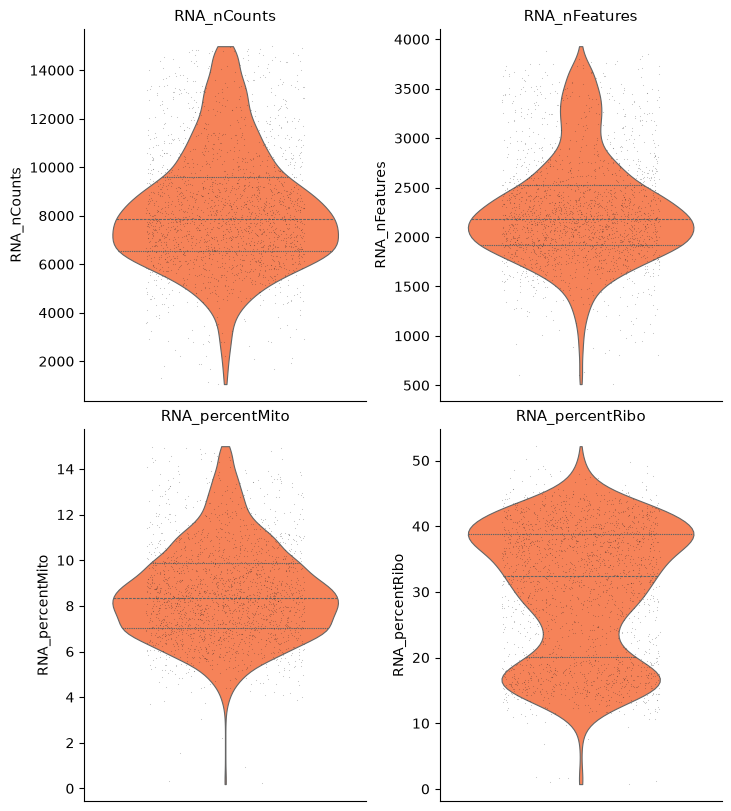

In [7]:
ds.plots.distribution(
    keys=qc_cols,
    kind='violin',
    max_points=2000,
    color='coral',
)

In [8]:
ds.RNA.sf

1000

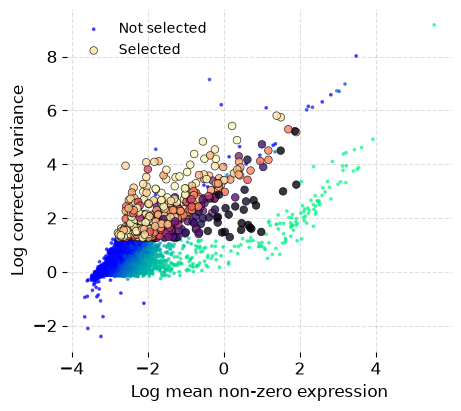

Selected genes: 498


,names,nCells,I__hvgs
0,MIR1302-2HG,0,False
1,FAM138A,0,False
2,OR4F5,0,False
3,AL627309.1,49,False
4,AL627309.3,3,False


In [9]:
ds.mark_hvgs(
    min_cells=20,
    top_n=500,
    min_mean=-3,
    max_mean=2,
    max_var=6,
    show_plot=True,
)
print('Selected genes:', int(ds.RNA.feats.fetch_all('I__hvgs').sum()))
ds.RNA.feats.to_pandas_dataframe(
    ['names', 'nCells', 'I__hvgs']
).head()

In [10]:
ds.run_normalization(feat_key='hvgs')
ds.run_pca(dims=15)
ds.build_embedding_initialization()
ds.build_ann_index()
ds.query_neighbors(k=11)
ds.build_connectivity_map()

ds.load_graph()

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 43340 stored elements and shape (3940, 3940)>

In [11]:
ds.run_umap(
    n_epochs=250,
    spread=5,
    min_dist=1,
    parallel=True
)
ds.cells.to_pandas_dataframe(
    columns=['RNA_UMAP1', 'RNA_UMAP2'],
    key='I'
).head()

,RNA_UMAP1,RNA_UMAP2
0,17.220438,10.788121
1,22.012714,26.035812
3,-3.922423,30.844023
4,-17.272848,12.874337
6,-5.410826,-32.525539


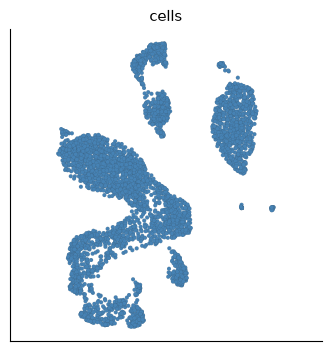

In [12]:
ds.plots.embedding(layout_key='RNA_UMAP')

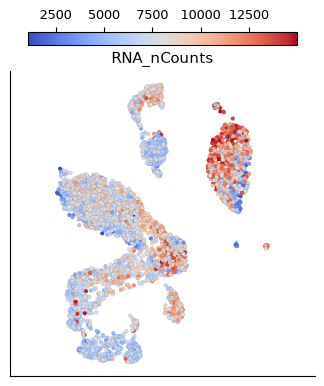

In [13]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='RNA_nCounts',
    color_scale=splt.ColorScale(cmap='coolwarm'),
)

In [14]:
ds.run_leiden_clustering(resolution=0.5)
ds.cells.to_pandas_dataframe(
    columns=['RNA_leiden_cluster'],
    key='I'
)['RNA_leiden_cluster'].value_counts().sort_index()

RNA_leiden_cluster
1     1279
2      696
3      591
4      365
5      317
6      251
7      247
8      139
9       28
10      15
11      12
Name: count, dtype: int64

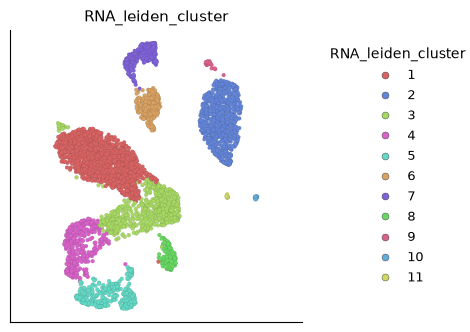

In [15]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='RNA_leiden_cluster',
)

In [16]:
ds.run_marker_search(
    group_key='RNA_leiden_cluster',
    gene_batch_size=100
)

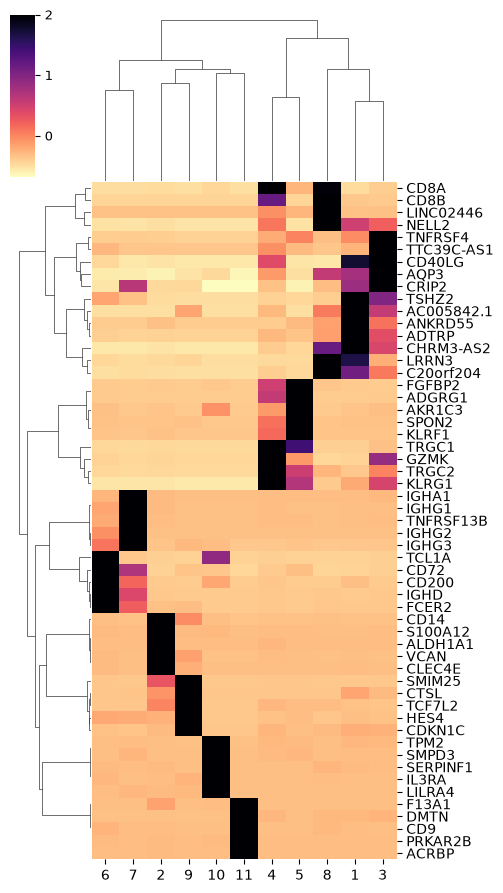

In [17]:
ds.plots.marker_heatmap(
    group_key='RNA_leiden_cluster',
    topn=5,
    figsize=(5, 9)
)

In [18]:
df = ds.get_markers(
    group_key='RNA_leiden_cluster',
    group_id='1',
    min_score=-1,
    min_frac_exp=-1
)
df.head()

,group_id,feature_name,score,mean,mean_rest,frac_exp,frac_exp_rest,fold_change,p_value,feature_index
0,1,ADTRP,0.63566,0.04224,0.00278,0.23847,0.02067,15.18069,1.631045e-110,4325
1,1,TSHZ2,0.58529,0.07375,0.00940,0.33542,0.04284,7.84940,5.096755e-138,12544
2,1,ANKRD55,0.55780,0.02195,0.00098,0.14934,0.00789,22.31694,4.349972e-76,3795
3,1,AC005842.1,0.52300,0.02595,0.00232,0.16341,0.01691,11.17710,2.243872e-69,8521
4,1,CHRM3-AS2,0.50847,0.06830,0.00756,0.38624,0.05411,9.03975,6.124634e-159,1437


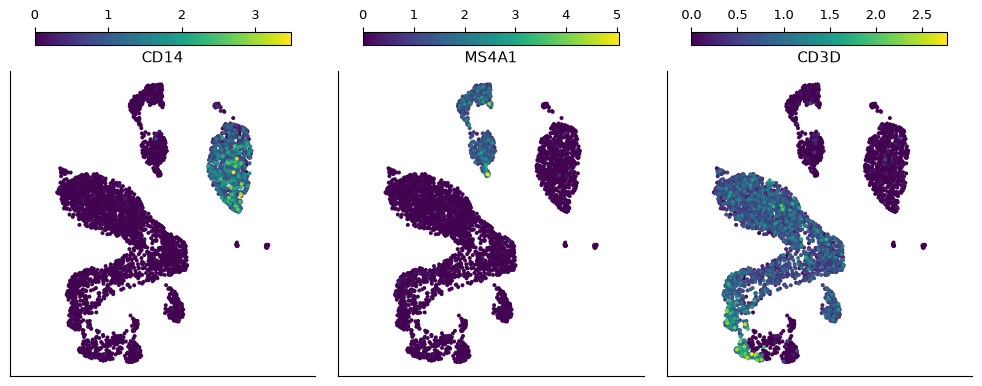

In [19]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by=['CD14', 'MS4A1', 'CD3D'],
    n_columns=3,
    sort_values=True,
)

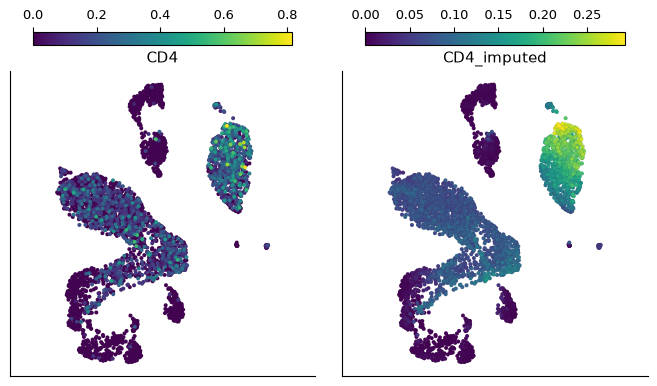

In [20]:
imputed_cd4 = ds.get_imputed(feature_name='CD4', t=2)
ds.cells.insert('CD4_imputed', imputed_cd4, overwrite=True)
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by=['CD4', 'CD4_imputed'],
    n_columns=2,
    sort_values=True,
)